In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path("../data/processed/customer_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (49997, 27)


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49997 entries, 0 to 49996
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   49997 non-null  int64  
 1   Year_Birth           49997 non-null  int64  
 2   Education            49997 non-null  object 
 3   Marital_Status       49997 non-null  object 
 4   Income               49997 non-null  float64
 5   Kidhome              49997 non-null  int64  
 6   Teenhome             49997 non-null  int64  
 7   Dt_Customer          49997 non-null  object 
 8   Recency              49997 non-null  int64  
 9   MntWines             49997 non-null  int64  
 10  MntFruits            49997 non-null  int64  
 11  MntMeatProducts      49997 non-null  int64  
 12  MntFishProducts      49997 non-null  int64  
 13  MntSweetProducts     49997 non-null  int64  
 14  MntGoldProds         49997 non-null  int64  
 15  NumDealsPurchases    49997 non-null 

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
customer_id = df["ID"].copy()

print("Customer IDs:", customer_id.nunique())
print("Total rows:", len(df))

Customer IDs: 49997
Total rows: 49997


## 1. Feature Engineering

The goal of feature engineering is to convert the cleaned customer data into meaningful customer-level behavioral and demographic features.

We will create:

- Age
- TotalChildren
- CustomerTenureDays
- TotalSpending
- TotalPurchases
- DealPurchaseShare
- WebPurchaseShare
- CatalogPurchaseShare
- StorePurchaseShare
- CampaignAcceptedCount

Customer ID will be preserved separately for final output and will not be used as an ML feature.

In [8]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    errors="coerce"
)

print("Minimum customer date:", df["Dt_Customer"].min())
print("Maximum customer date:", df["Dt_Customer"].max())

Minimum customer date: 2012-07-30 00:00:00
Maximum customer date: 2014-06-29 00:00:00


In [9]:
reference_year = df["Dt_Customer"].dt.year.max()

df["Age"] = reference_year - df["Year_Birth"]

print(df[["Year_Birth", "Age"]].head())

   Year_Birth  Age
0        1957   57
1        1954   60
2        1965   49
3        1984   30
4        1981   33


In [10]:
df["TotalChildren"] = (
    df["Kidhome"] + df["Teenhome"]
)

df[["Kidhome", "Teenhome", "TotalChildren"]].head()

,Kidhome,Teenhome,TotalChildren
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


In [11]:
reference_date = df["Dt_Customer"].max()

df["CustomerTenureDays"] = (
    reference_date - df["Dt_Customer"]
).dt.days

df[
    ["Dt_Customer", "CustomerTenureDays"]
].head()

,Dt_Customer,CustomerTenureDays
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161


In [12]:
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

df["TotalSpending"] = df[spending_columns].sum(axis=1)

df[
    spending_columns + ["TotalSpending"]
].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalSpending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [13]:
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
]

df["TotalPurchases"] = df[purchase_columns].sum(axis=1)

df[
    purchase_columns + ["TotalPurchases"]
].head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,TotalPurchases
0,8,10,4,22
1,1,1,2,4
2,8,2,10,20
3,2,0,4,6
4,5,3,6,14


In [14]:
df["DealPurchaseShare"] = np.where(
    df["TotalPurchases"] > 0,
    df["NumDealsPurchases"] / df["TotalPurchases"],
    0.0
)

df[
    ["NumDealsPurchases", "TotalPurchases", "DealPurchaseShare"]
].head()

,NumDealsPurchases,TotalPurchases,DealPurchaseShare
0,3,22,0.136364
1,2,4,0.500000
2,1,20,0.050000
3,2,6,0.333333
4,5,14,0.357143


In [15]:
df["WebPurchaseShare"] = np.where(
    df["TotalPurchases"] > 0,
    df["NumWebPurchases"] / df["TotalPurchases"],
    0.0
)

df["CatalogPurchaseShare"] = np.where(
    df["TotalPurchases"] > 0,
    df["NumCatalogPurchases"] / df["TotalPurchases"],
    0.0
)

df["StorePurchaseShare"] = np.where(
    df["TotalPurchases"] > 0,
    df["NumStorePurchases"] / df["TotalPurchases"],
    0.0
)

df[
    [
        "WebPurchaseShare",
        "CatalogPurchaseShare",
        "StorePurchaseShare",
    ]
].head()

,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare
0,0.363636,0.454545,0.181818
1,0.250000,0.250000,0.500000
2,0.400000,0.100000,0.500000
3,0.333333,0.000000,0.666667
4,0.357143,0.214286,0.428571


In [16]:
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
]

df["CampaignAcceptedCount"] = (
    df[campaign_columns].sum(axis=1)
)

df[
    campaign_columns + ["CampaignAcceptedCount"]
].head()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,CampaignAcceptedCount
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [17]:
engineered_columns = [
    "ID",
    "Age",
    "Income",
    "Education",
    "Marital_Status",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

df[engineered_columns].head(10)

,ID,Age,Income,Education,Marital_Status,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount
0,5524,57,58138.0,Graduation,Single,0,663,58,1617,22,0.136364,0.363636,0.454545,0.181818,7,0
1,2174,60,46344.0,Graduation,Single,2,113,38,27,4,0.500000,0.250000,0.250000,0.500000,5,0
2,4141,49,71613.0,Graduation,Together,0,312,26,776,20,0.050000,0.400000,0.100000,0.500000,4,0
3,6182,30,26646.0,Graduation,Together,1,139,26,53,6,0.333333,0.333333,0.000000,0.666667,6,0
4,5324,33,58293.0,PhD,Married,1,161,94,422,14,0.357143,0.357143,0.214286,0.428571,5,0
5,7446,47,62513.0,Master,Together,1,293,16,716,20,0.100000,0.300000,0.200000,0.500000,6,0
6,965,43,55635.0,Graduation,Divorced,1,593,34,590,17,0.235294,0.411765,0.176471,0.411765,6,0
7,6177,29,33454.0,PhD,Married,1,417,32,169,8,0.250000,0.500000,0.000000,0.500000,8,0
8,4855,40,30351.0,PhD,Together,1,388,19,46,5,0.200000,0.600000,0.000000,0.400000,9,0
9,5899,64,5648.0,PhD,Together,2,108,68,49,1,1.000000,1.000000,0.000000,0.000000,20,1


In [18]:
df[engineered_columns].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,49997.0,NaN,NaN,NaN,33752.451047,14805.469893,0.0,21454.0,33953.0,46452.0,58951.0
Age,49997.0,NaN,NaN,NaN,45.16213,11.741091,18.0,37.0,44.0,55.0,74.0
Income,49997.0,NaN,NaN,NaN,51987.467598,21090.509103,1641.0495,35469.909988,51615.901476,68355.126592,117682.951499
Education,49997,5,Graduation,25162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,49997,5,Married,19546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalChildren,49997.0,NaN,NaN,NaN,0.946437,0.753164,0.0,0.0,1.0,1.0,3.0
CustomerTenureDays,49997.0,NaN,NaN,NaN,353.619517,201.812862,0.0,181.0,353.0,529.0,699.0
Recency,49997.0,NaN,NaN,NaN,49.233534,29.011902,0.0,24.0,50.0,74.0,99.0
TotalSpending,49997.0,NaN,NaN,NaN,609.567314,605.816411,5.0,69.0,396.0,1053.0,2833.0
TotalPurchases,49997.0,NaN,NaN,NaN,12.597456,7.973397,0.0,6.0,12.0,18.0,52.0


In [19]:
OUTPUT_PATH = Path("../data/processed/customer_feature_engineered.csv")

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved feature-engineered data to: {OUTPUT_PATH}")

Saved feature-engineered data to: ..\data\processed\customer_feature_engineered.csv


## 2. Feature Selection

The purpose of this stage is to select informative and non-redundant customer features for clustering.

Customer ID is retained separately for final output but excluded from the ML feature matrix.

Business outcome variables such as `Response` and `Complain` will initially be excluded from clustering and used later for segment profiling.

We will inspect feature relationships, redundancy, and business relevance before finalizing the feature set.

In [20]:
candidate_features = [
    "Age",
    "Income",
    "Education",
    "Marital_Status",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

print("Candidate features:")
for feature in candidate_features:
    print("✓", feature)

Candidate features:
✓ Age
✓ Income
✓ Education
✓ Marital_Status
✓ TotalChildren
✓ CustomerTenureDays
✓ Recency
✓ TotalSpending
✓ TotalPurchases
✓ DealPurchaseShare
✓ WebPurchaseShare
✓ CatalogPurchaseShare
✓ StorePurchaseShare
✓ NumWebVisitsMonth
✓ CampaignAcceptedCount


In [21]:
numeric_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

categorical_features = [
    "Education",
    "Marital_Status",
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 2


In [22]:
correlation_matrix = df[numeric_features].corr()

correlation_matrix

,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount
Age,1.000000,0.191962,0.104840,-0.016478,0.025660,0.100442,0.148177,-0.043375,-0.004547,0.095364,-0.066820,-0.076130,-0.010061
Income,0.191962,1.000000,-0.346067,-0.030429,0.006992,0.797005,0.671837,-0.315176,-0.111637,0.447335,-0.214402,-0.481445,0.368879
TotalChildren,0.104840,-0.346067,1.000000,-0.017904,0.017110,-0.497460,-0.342270,0.294792,0.128446,-0.317263,0.122356,0.310650,-0.245104
CustomerTenureDays,-0.016478,-0.030429,-0.017904,1.000000,0.024260,0.151615,0.140880,0.025941,0.052412,0.038354,-0.066091,0.196047,-0.016856
Recency,0.025660,0.006992,0.017110,0.024260,1.000000,0.019416,0.011257,-0.004865,-0.009450,0.034421,-0.019271,-0.015672,-0.009166
TotalSpending,0.100442,0.797005,-0.497460,0.151615,0.019416,1.000000,0.739419,-0.296255,-0.109027,0.508405,-0.257570,-0.369396,0.456036
TotalPurchases,0.148177,0.671837,-0.342270,0.140880,0.011257,0.739419,1.000000,-0.340624,-0.010133,0.406473,-0.246908,-0.285625,0.276278
DealPurchaseShare,-0.043375,-0.315176,0.294792,0.025941,-0.004865,-0.296255,-0.340624,1.000000,0.056662,-0.136412,0.073748,0.208643,-0.128798
WebPurchaseShare,-0.004547,-0.111637,0.128446,0.052412,-0.009450,-0.109027,-0.010133,0.056662,1.000000,-0.289629,-0.629045,0.198181,-0.038794
CatalogPurchaseShare,0.095364,0.447335,-0.317263,0.038354,0.034421,0.508405,0.406473,-0.136412,-0.289629,1.000000,-0.467773,-0.294997,0.239066


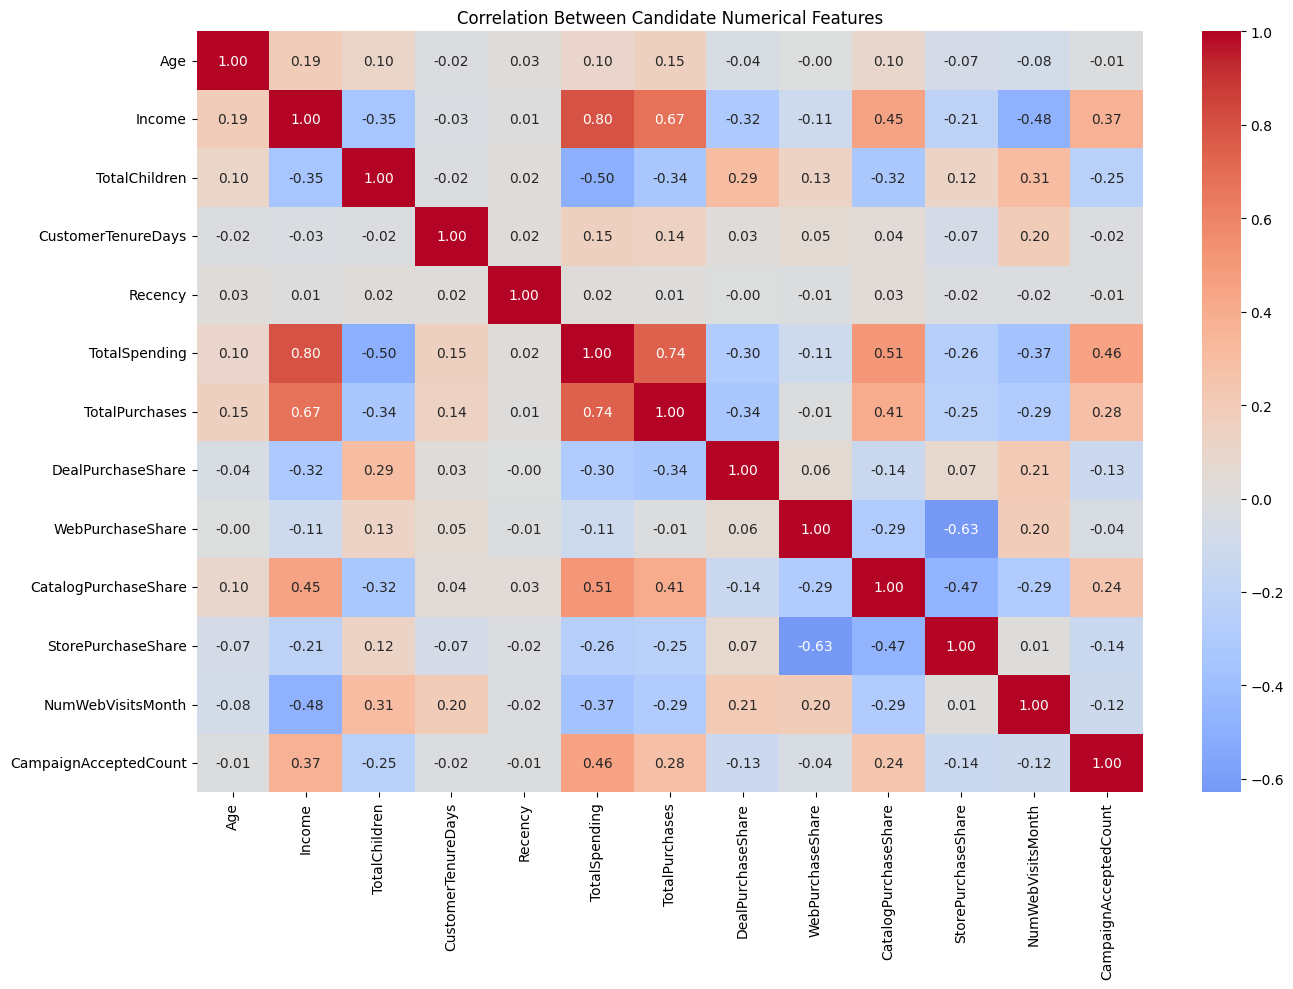

In [23]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Between Candidate Numerical Features")
plt.tight_layout()
plt.show()

In [24]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49997.0,45.162130,11.741091,18.0000,37.000000,44.000000,55.000000,74.000000
Income,49997.0,51987.467598,21090.509103,1641.0495,35469.909988,51615.901476,68355.126592,117682.951499
TotalChildren,49997.0,0.946437,0.753164,0.0000,0.000000,1.000000,1.000000,3.000000
CustomerTenureDays,49997.0,353.619517,201.812862,0.0000,181.000000,353.000000,529.000000,699.000000
Recency,49997.0,49.233534,29.011902,0.0000,24.000000,50.000000,74.000000,99.000000
TotalSpending,49997.0,609.567314,605.816411,5.0000,69.000000,396.000000,1053.000000,2833.000000
TotalPurchases,49997.0,12.597456,7.973397,0.0000,6.000000,12.000000,18.000000,52.000000
DealPurchaseShare,49997.0,0.283187,0.464166,0.0000,0.045455,0.166667,0.375000,25.000000
WebPurchaseShare,49997.0,0.326489,0.206524,0.0000,0.187500,0.320000,0.454545,1.000000
CatalogPurchaseShare,49997.0,0.170104,0.174293,0.0000,0.000000,0.142857,0.277778,1.000000


In [25]:
X = df[candidate_features].copy()

X.head()

,Age,Income,Education,Marital_Status,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount
0,57,58138.0,Graduation,Single,0,663,58,1617,22,0.136364,0.363636,0.454545,0.181818,7,0
1,60,46344.0,Graduation,Single,2,113,38,27,4,0.500000,0.250000,0.250000,0.500000,5,0
2,49,71613.0,Graduation,Together,0,312,26,776,20,0.050000,0.400000,0.100000,0.500000,4,0
3,30,26646.0,Graduation,Together,1,139,26,53,6,0.333333,0.333333,0.000000,0.666667,6,0
4,33,58293.0,PhD,Married,1,161,94,422,14,0.357143,0.357143,0.214286,0.428571,5,0


In [26]:
X.shape

(49997, 15)

In [27]:
X.dtypes

Age                        int64
Income                   float64
Education                 object
Marital_Status            object
TotalChildren              int64
CustomerTenureDays         int64
Recency                    int64
TotalSpending              int64
TotalPurchases             int64
DealPurchaseShare        float64
WebPurchaseShare         float64
CatalogPurchaseShare     float64
StorePurchaseShare       float64
NumWebVisitsMonth          int64
CampaignAcceptedCount      int64
dtype: object

In [28]:
candidate_features = [
    "Age",
    "Income",
    "Education",
    "Marital_Status",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

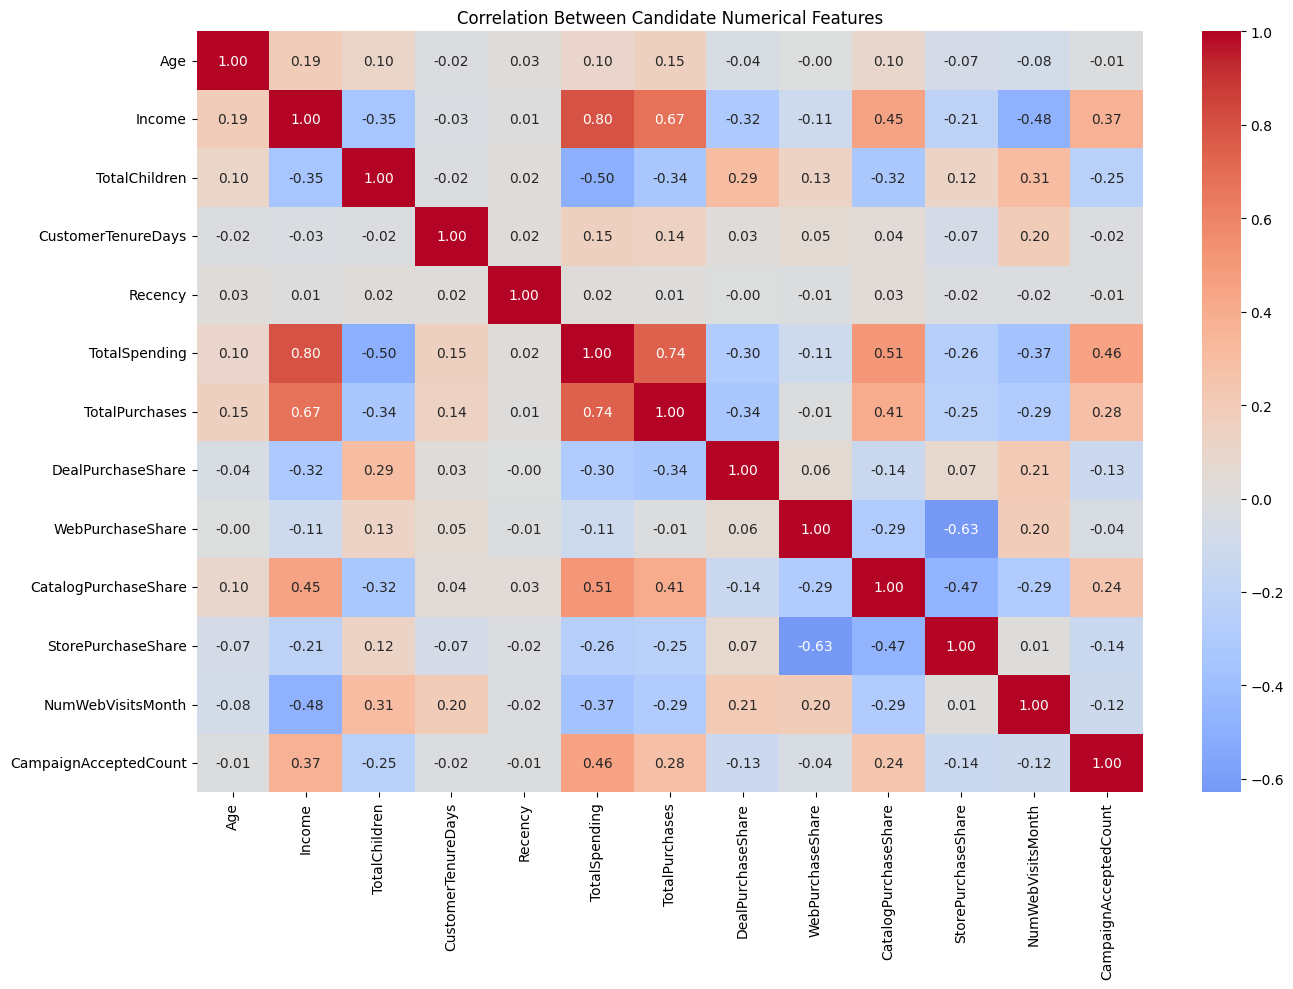

In [29]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Between Candidate Numerical Features")
plt.tight_layout()
plt.show()

In [30]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49997.0,45.162130,11.741091,18.0000,37.000000,44.000000,55.000000,74.000000
Income,49997.0,51987.467598,21090.509103,1641.0495,35469.909988,51615.901476,68355.126592,117682.951499
TotalChildren,49997.0,0.946437,0.753164,0.0000,0.000000,1.000000,1.000000,3.000000
CustomerTenureDays,49997.0,353.619517,201.812862,0.0000,181.000000,353.000000,529.000000,699.000000
Recency,49997.0,49.233534,29.011902,0.0000,24.000000,50.000000,74.000000,99.000000
TotalSpending,49997.0,609.567314,605.816411,5.0000,69.000000,396.000000,1053.000000,2833.000000
TotalPurchases,49997.0,12.597456,7.973397,0.0000,6.000000,12.000000,18.000000,52.000000
DealPurchaseShare,49997.0,0.283187,0.464166,0.0000,0.045455,0.166667,0.375000,25.000000
WebPurchaseShare,49997.0,0.326489,0.206524,0.0000,0.187500,0.320000,0.454545,1.000000
CatalogPurchaseShare,49997.0,0.170104,0.174293,0.0000,0.000000,0.142857,0.277778,1.000000


## 2.1 Feature Selection Decision

Based on business relevance and correlation analysis:

### Numerical clustering features
- Age
- Income
- TotalChildren
- CustomerTenureDays
- Recency
- TotalSpending
- TotalPurchases
- DealPurchaseShare
- WebPurchaseShare
- CatalogPurchaseShare
- NumWebVisitsMonth
- CampaignAcceptedCount

### Categorical clustering features
- Education
- Marital_Status

### Excluded from clustering
- ID: customer identifier only
- Response: campaign outcome, reserved for profiling
- Complain: customer outcome/risk indicator, reserved for profiling
- StorePurchaseShare: redundant because purchase-channel shares sum approximately to 1

In [31]:
selected_numeric_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

selected_categorical_features = [
    "Education",
    "Marital_Status",
]

excluded_features = [
    "ID",
    "Response",
    "Complain",
    "StorePurchaseShare",
]

print("Selected numerical features:")
for feature in selected_numeric_features:
    print("✓", feature)

print("\nSelected categorical features:")
for feature in selected_categorical_features:
    print("✓", feature)

print("\nExcluded features:")
for feature in excluded_features:
    print("✗", feature)

Selected numerical features:
✓ Age
✓ Income
✓ TotalChildren
✓ CustomerTenureDays
✓ Recency
✓ TotalSpending
✓ TotalPurchases
✓ DealPurchaseShare
✓ WebPurchaseShare
✓ CatalogPurchaseShare
✓ NumWebVisitsMonth
✓ CampaignAcceptedCount

Selected categorical features:
✓ Education
✓ Marital_Status

Excluded features:
✗ ID
✗ Response
✗ Complain
✗ StorePurchaseShare


In [32]:
selected_features = (
    selected_numeric_features
    + selected_categorical_features
)

missing_selected = [
    feature
    for feature in selected_features
    if feature not in df.columns
]

print("Missing selected features:", missing_selected)
print("Total selected features:", len(selected_features))

Missing selected features: []
Total selected features: 14


## 3. Feature Scaling and Preprocessing

The selected numerical features have different ranges, so scaling is required for distance-based clustering.

We will:

1. Scale numerical features using StandardScaler.
2. Encode categorical features using OneHotEncoder.
3. Combine both transformations using ColumnTransformer.
4. Keep the preprocessing pipeline reusable for future inference.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

print("Preprocessing tools imported successfully.")

Preprocessing tools imported successfully.


In [34]:
selected_numeric_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
]

selected_categorical_features = [
    "Education",
    "Marital_Status",
]

selected_features = (
    selected_numeric_features
    + selected_categorical_features
)

print("Numerical:", len(selected_numeric_features))
print("Categorical:", len(selected_categorical_features))
print("Total:", len(selected_features))

Numerical: 12
Categorical: 2
Total: 14


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            selected_numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            selected_categorical_features,
        ),
    ],
    remainder="drop",
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [36]:
X = df[selected_features].copy()

print("Input feature matrix shape:", X.shape)
X.head()

Input feature matrix shape: (49997, 14)


,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Education,Marital_Status
0,57,58138.0,0,663,58,1617,22,0.136364,0.363636,0.454545,7,0,Graduation,Single
1,60,46344.0,2,113,38,27,4,0.500000,0.250000,0.250000,5,0,Graduation,Single
2,49,71613.0,0,312,26,776,20,0.050000,0.400000,0.100000,4,0,Graduation,Together
3,30,26646.0,1,139,26,53,6,0.333333,0.333333,0.000000,6,0,Graduation,Together
4,33,58293.0,1,161,94,422,14,0.357143,0.357143,0.214286,5,0,PhD,Married


In [37]:
X_processed = preprocessor.fit_transform(X)

print("Processed matrix shape:", X_processed.shape)

Processed matrix shape: (49997, 22)


In [38]:
feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=df.index,
)

X_processed_df.head()

,numerical__Age,numerical__Income,numerical__TotalChildren,numerical__CustomerTenureDays,numerical__Recency,numerical__TotalSpending,numerical__TotalPurchases,numerical__DealPurchaseShare,numerical__WebPurchaseShare,numerical__CatalogPurchaseShare,numerical__NumWebVisitsMonth,numerical__CampaignAcceptedCount,categorical__Education_2nd Cycle,categorical__Education_Basic,categorical__Education_Graduation,categorical__Education_Master,categorical__Education_PhD,categorical__Marital_Status_Divorced,categorical__Marital_Status_Married,categorical__Marital_Status_Single,categorical__Marital_Status_Together,categorical__Marital_Status_Widow
0,1.008253,0.291629,-1.256626,1.533022,0.302171,1.662951,1.179251,-0.316320,0.179871,1.631992,0.514008,-0.436769,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.263768,-0.267586,1.398863,-1.192302,-0.387208,-0.961633,-1.078278,0.467108,-0.370367,0.458406,-0.089393,-0.436769,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.326878,0.930548,-1.256626,-0.206230,-0.800836,0.274727,0.928415,-0.502384,0.355947,-0.402223,-0.391094,-0.436769,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.291386,-1.201570,0.071118,-1.063469,-0.800836,-0.918715,-0.827442,0.108037,0.033141,-0.975977,0.212307,-0.436769,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.035871,0.298978,0.071118,-0.954456,1.543053,-0.309614,0.175905,0.159333,0.148428,0.253495,-0.089393,-0.436769,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [39]:
X_processed_df.shape

(49997, 22)

In [40]:
X_processed_df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
numerical__Age,49997.0,2.033695e-16,1.000010,-2.313448,-0.695183,-0.098981,0.837909,2.456174
numerical__Income,49997.0,1.506441e-17,1.000010,-2.387184,-0.783183,-0.017618,0.776075,3.114962
numerical__TotalChildren,49997.0,5.116215e-18,1.000010,-1.256626,-1.256626,0.071118,0.071118,2.726608
numerical__CustomerTenureDays,49997.0,-9.862925e-17,1.000010,-1.752232,-0.855353,-0.003070,0.869034,1.711407
numerical__Recency,49997.0,6.935313e-17,1.000010,-1.697029,-0.869774,0.026419,0.853674,1.715398
numerical__TotalSpending,49997.0,-6.366845e-17,1.000010,-0.997948,-0.892305,-0.352532,0.731966,3.670179
numerical__TotalPurchases,49997.0,9.948195e-17,1.000010,-1.579952,-0.827442,-0.074932,0.677578,4.941801
numerical__DealPurchaseShare,49997.0,2.785495e-17,1.000010,-0.610105,-0.512176,-0.251034,0.197805,53.250521
numerical__WebPurchaseShare,49997.0,6.906890e-17,1.000010,-1.580890,-0.672998,-0.031421,0.620061,3.261201
numerical__CatalogPurchaseShare,49997.0,2.700224e-17,1.000010,-0.975977,-0.975977,-0.156329,0.617782,4.761555


In [41]:
X_processed_df[
    [
        feature
        for feature in X_processed_df.columns
        if feature.startswith("numerical__")
    ]
].agg(["mean", "std"]).T.head(20)

,mean,std
numerical__Age,2.033695e-16,1.00001
numerical__Income,1.506441e-17,1.00001
numerical__TotalChildren,5.116215e-18,1.00001
numerical__CustomerTenureDays,-9.862925e-17,1.00001
numerical__Recency,6.935313e-17,1.00001
numerical__TotalSpending,-6.366845e-17,1.00001
numerical__TotalPurchases,9.948195e-17,1.00001
numerical__DealPurchaseShare,2.785495e-17,1.00001
numerical__WebPurchaseShare,6.906890e-17,1.00001
numerical__CatalogPurchaseShare,2.700224e-17,1.00001


In [42]:
categorical_output_columns = [
    feature
    for feature in X_processed_df.columns
    if feature.startswith("categorical__")
]

print("Encoded categorical columns:")
for feature in categorical_output_columns:
    print(feature)

Encoded categorical columns:
categorical__Education_2nd Cycle
categorical__Education_Basic
categorical__Education_Graduation
categorical__Education_Master
categorical__Education_PhD
categorical__Marital_Status_Divorced
categorical__Marital_Status_Married
categorical__Marital_Status_Single
categorical__Marital_Status_Together
categorical__Marital_Status_Widow


In [43]:
import joblib

In [44]:
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

In [45]:
preprocessor_path = models_path / "preprocessor.pkl"

joblib.dump(
    preprocessor,
    preprocessor_path,
)

print(f"Preprocessor saved to: {preprocessor_path}")

Preprocessor saved to: ..\models\preprocessor.pkl


In [46]:
print("NaN values:", np.isnan(X_processed).sum())
print("Infinite values:", np.isinf(X_processed).sum())

NaN values: 0
Infinite values: 0


In [47]:
print("Processed matrix shape:", X_processed.shape)

Processed matrix shape: (49997, 22)


In [49]:
print("NaN values:", np.isnan(X_processed).sum())
print("Infinite values:", np.isinf(X_processed).sum())

NaN values: 0
Infinite values: 0


In [50]:
X_processed_df.shape

(49997, 22)

## 4. Clustering — K-Means

K-Means will be used as the first clustering candidate.

The number of clusters will not be assumed beforehand. We will evaluate several candidate values of K using:

- Elbow Method
- Silhouette Score

The final value of K will be selected based on both clustering quality and business interpretability.

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Clustering libraries imported successfully.")

Clustering libraries imported successfully.


In [52]:
RANDOM_STATE = 42

sample_size = min(10000, len(X_processed_df))

sample_df = X_processed_df.sample(
    n=sample_size,
    random_state=RANDOM_STATE,
)

X_sample = sample_df.to_numpy()

print("Sample size:", X_sample.shape)

Sample size: (10000, 22)


In [53]:
k_values = range(2, 11)

inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    model.fit(X_sample)

    inertias.append(model.inertia_)

print("Elbow experiment completed.")

Elbow experiment completed.


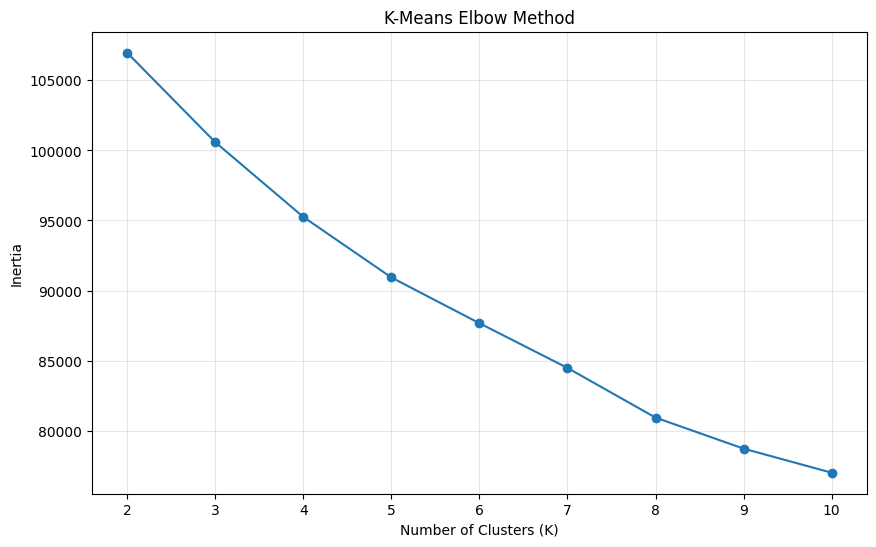

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

In [55]:
silhouette_scores = []
davies_bouldin_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    silhouette = silhouette_score(
        X_sample,
        labels,
    )

    db_score = davies_bouldin_score(
        X_sample,
        labels,
    )

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(db_score)

    print(
        f"K={k} | "
        f"Silhouette={silhouette:.4f} | "
        f"Davies-Bouldin={db_score:.4f}"
    )

K=2 | Silhouette=0.1969 | Davies-Bouldin=1.8313
K=3 | Silhouette=0.1079 | Davies-Bouldin=2.3508
K=4 | Silhouette=0.1068 | Davies-Bouldin=2.5442
K=5 | Silhouette=0.0982 | Davies-Bouldin=2.4297
K=6 | Silhouette=0.0947 | Davies-Bouldin=2.3755
K=7 | Silhouette=0.0962 | Davies-Bouldin=2.2135
K=8 | Silhouette=0.0941 | Davies-Bouldin=2.0400
K=9 | Silhouette=0.0958 | Davies-Bouldin=2.0074
K=10 | Silhouette=0.0916 | Davies-Bouldin=2.0429


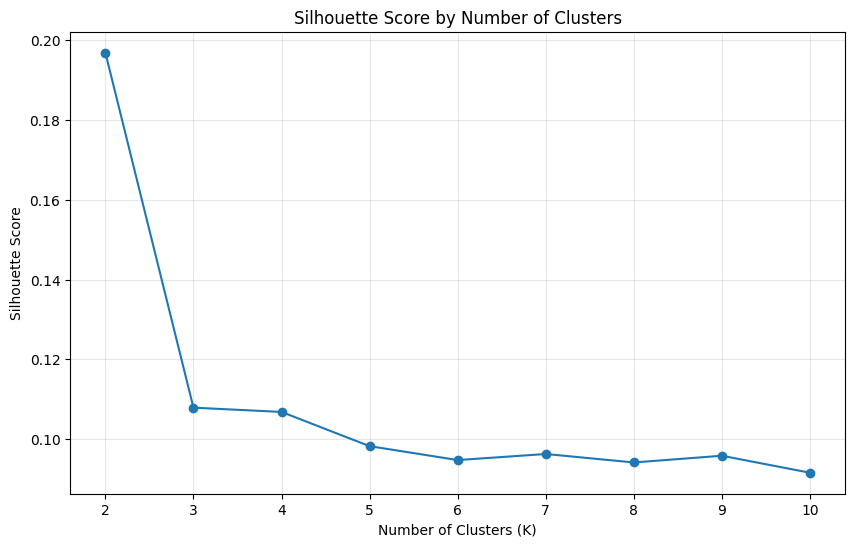

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

In [58]:
results = pd.DataFrame(
    {
        "K": list(k_values),
        "Inertia": inertias,
        "Silhouette": silhouette_scores,
        "Davies_Bouldin": davies_bouldin_scores,
    }
)

results

,K,Inertia,Silhouette,Davies_Bouldin
0,2,106972.260909,0.196902,1.831295
1,3,100591.268856,0.107874,2.350825
2,4,95256.150940,0.106800,2.544241
3,5,90936.240777,0.098219,2.429688
4,6,87669.168575,0.094728,2.375471
5,7,84478.293566,0.096250,2.213507
6,8,80934.336780,0.094128,2.039993
7,9,78719.375821,0.095812,2.007354
8,10,77000.956927,0.091554,2.042855


In [59]:
candidate_k = [2, 3, 4]

cluster_size_results = {}

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    counts = pd.Series(labels).value_counts().sort_index()

    cluster_size_results[k] = counts

    print(f"\nK = {k}")
    print(counts)
    print(
        "Percent:",
        (counts / len(labels) * 100).round(2).tolist()
    )


K = 2
0    4228
1    5772
Name: count, dtype: int64
Percent: [42.28, 57.72]

K = 3
0    4616
1    2312
2    3072
Name: count, dtype: int64
Percent: [46.16, 23.12, 30.72]

K = 4
0    3302
1    2624
2    1098
3    2976
Name: count, dtype: int64
Percent: [33.02, 26.24, 10.98, 29.76]


In [60]:
sample_indices = sample_df.index

profile_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
    "Response",
    "Complain",
]

In [61]:
for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    profile_df = df.loc[sample_indices, profile_features].copy()
    profile_df["Cluster"] = labels

    print("\n" + "=" * 70)
    print(f"CLUSTER PROFILE FOR K = {k}")
    print("=" * 70)

    print(
        profile_df.groupby("Cluster")[profile_features]
        .mean()
        .round(2)
    )


CLUSTER PROFILE FOR K = 2
           Age    Income  TotalChildren  CustomerTenureDays  Recency  \
Cluster                                                                
0        47.12  70986.21           0.49              370.30    48.98   
1        43.98  38298.71           1.27              343.75    48.90   

         TotalSpending  TotalPurchases  DealPurchaseShare  WebPurchaseShare  \
Cluster                                                                       
0              1199.77           19.56               0.10              0.28   
1               183.77            7.63               0.42              0.36   

         CatalogPurchaseShare  StorePurchaseShare  NumWebVisitsMonth  \
Cluster                                                                
0                        0.28                0.44               3.55   
1                        0.09                0.54               6.51   

         CampaignAcceptedCount  Response  Complain  
Cluster                  

In [62]:
for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    profile_df = df.loc[sample_indices, profile_features].copy()
    profile_df["Cluster"] = labels

    counts = (
        profile_df["Cluster"]
        .value_counts()
        .sort_index()
        .rename("CustomerCount")
    )

    profile = (
        profile_df
        .groupby("Cluster")[profile_features]
        .mean()
        .round(2)
    )

    profile["CustomerCount"] = counts

    print(f"\nK = {k}")
    display(profile)


K = 2


,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,CustomerCount
Cluster,,,,,,,,,,,,,,,,
0,47.12,70986.21,0.49,370.30,48.98,1199.77,19.56,0.10,0.28,0.28,0.44,3.55,0.56,0.21,0.01,4228
1,43.98,38298.71,1.27,343.75,48.90,183.77,7.63,0.42,0.36,0.09,0.54,6.51,0.10,0.10,0.01,5772



K = 3


,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,CustomerCount
Cluster,,,,,,,,,,,,,,,,
0,42.24,34661.29,1.28,334.18,48.78,112.97,5.96,0.46,0.34,0.08,0.56,6.65,0.09,0.1,0.01,4616
1,44.50,77034.80,0.14,336.43,49.37,1426.69,19.49,0.07,0.24,0.33,0.43,2.50,0.84,0.3,0.00,2312
2,50.53,59599.25,1.03,400.17,48.83,753.04,17.64,0.19,0.36,0.18,0.45,5.25,0.19,0.1,0.01,3072



K = 4


,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,CustomerCount
Cluster,,,,,,,,,,,,,,,,
0,48.03,67192.67,0.62,378.62,49.33,1037.22,19.29,0.12,0.28,0.26,0.45,3.73,0.12,0.12,0.01,3302
1,42.73,35421.06,1.24,285.20,48.78,98.83,5.57,0.44,0.17,0.11,0.70,5.74,0.09,0.06,0.01,2624
2,44.77,79481.70,0.20,344.49,48.91,1580.33,19.81,0.07,0.27,0.31,0.42,3.16,1.76,0.45,0.00,1098
3,44.76,40021.46,1.31,394.12,48.64,239.89,8.97,0.40,0.54,0.07,0.39,7.32,0.12,0.13,0.01,2976


In [63]:
for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    profile_df = df.loc[sample_indices, ["Response", "Complain"]].copy()
    profile_df["Cluster"] = labels

    print(f"\nK = {k}")
    print(
        profile_df.groupby("Cluster")[["Response", "Complain"]]
        .mean()
        .round(3)
    )


K = 2
         Response  Complain
Cluster                    
0           0.211     0.009
1           0.098     0.009

K = 3
         Response  Complain
Cluster                    
0           0.099     0.009
1           0.297     0.004
2           0.103     0.012

K = 4
         Response  Complain
Cluster                    
0           0.122     0.011
1           0.065     0.008
2           0.453     0.004
3           0.131     0.009


In [64]:
k = 3

model_k3 = KMeans(
    n_clusters=k,
    random_state=RANDOM_STATE,
    n_init=10,
)

labels_k3 = model_k3.fit_predict(X_sample)

cluster_counts = (
    pd.Series(labels_k3)
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_counts / len(labels_k3) * 100
).round(2)

cluster_summary = pd.DataFrame({
    "CustomerCount": cluster_counts,
    "Percentage": cluster_percentages,
})

cluster_summary

,CustomerCount,Percentage
0,4616,46.16
1,2312,23.12
2,3072,30.72


## 4.1 Final K-Means Model

Based on the clustering experiments:

- K=2 produced the strongest internal metrics but only created a coarse two-group segmentation.
- K=3 produced three balanced and business-interpretable customer groups.
- K=4 provided additional detail but had weaker internal clustering metrics.

We therefore proceed with K=3 as the selected business segmentation configuration.

In [65]:
FINAL_K = 3

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10,
)

final_labels = final_kmeans.fit_predict(X_processed)

print("Final K-Means training completed.")
print("Customers:", len(final_labels))
print("Number of clusters:", FINAL_K)

Final K-Means training completed.
Customers: 49997
Number of clusters: 3


In [66]:
segmented_df = df[["ID"]].copy()

segmented_df["Cluster"] = final_labels

segmented_df.head(10)

,ID,Cluster
0,5524,2
1,2174,1
2,4141,2
3,6182,1
4,5324,1
5,7446,2
6,965,2
7,6177,1
8,4855,1
9,5899,1


In [67]:
final_cluster_counts = (
    segmented_df["Cluster"]
    .value_counts()
    .sort_index()
)

final_cluster_percentages = (
    final_cluster_counts / len(segmented_df) * 100
).round(2)

final_cluster_summary = pd.DataFrame({
    "CustomerCount": final_cluster_counts,
    "Percentage": final_cluster_percentages,
})

final_cluster_summary

,CustomerCount,Percentage
Cluster,,
0,5537,11.07
1,26683,53.37
2,17777,35.56


In [68]:
print("Final inertia:", final_kmeans.inertia_)

Final inertia: 495196.8282383289


In [69]:
final_sample_labels = final_kmeans.predict(X_sample)

final_sample_silhouette = silhouette_score(
    X_sample,
    final_sample_labels,
)

final_sample_db = davies_bouldin_score(
    X_sample,
    final_sample_labels,
)

print("Final sample silhouette:", round(final_sample_silhouette, 4))
print("Final sample Davies-Bouldin:", round(final_sample_db, 4))

Final sample silhouette: 0.1448
Final sample Davies-Bouldin: 2.1001


In [70]:
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

model_path = models_path / "clustering_model.pkl"

joblib.dump(
    final_kmeans,
    model_path,
)

print(f"Clustering model saved to: {model_path}")

Clustering model saved to: ..\models\clustering_model.pkl


In [71]:
profile_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
    "Response",
    "Complain",
]

profile_df = df[
    profile_features
].copy()

profile_df["Cluster"] = final_labels

full_cluster_profile = (
    profile_df
    .groupby("Cluster")[profile_features]
    .mean()
    .round(2)
)

full_cluster_counts = (
    profile_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("CustomerCount")
)

full_cluster_profile["CustomerCount"] = full_cluster_counts

full_cluster_profile

,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,CustomerCount
Cluster,,,,,,,,,,,,,,,,
0,44.21,79735.28,0.20,343.28,50.40,1578.39,19.95,0.07,0.27,0.31,0.42,3.08,1.79,0.47,0.00,5537
1,43.23,36627.73,1.28,339.48,48.68,152.61,6.95,0.43,0.36,0.09,0.54,6.67,0.10,0.10,0.01,26683
2,48.35,66399.59,0.67,378.06,49.70,993.70,18.78,0.13,0.30,0.25,0.45,3.92,0.13,0.12,0.01,17777


In [72]:
segmented_df["Cluster_Name"] = (
    segmented_df["Cluster"]
    .map(cluster_name_map)
)

OUTPUT_PATH = Path(
    "../data/processed/customer_segments.csv"
)

segmented_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved final segmentation to: {OUTPUT_PATH}")

NameError: name 'cluster_name_map' is not defined

In [ ]:
segmented_df["Cluster"] = final_labels

In [73]:
profile_features = [
    "Age",
    "Income",
    "TotalChildren",
    "CustomerTenureDays",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "DealPurchaseShare",
    "WebPurchaseShare",
    "CatalogPurchaseShare",
    "StorePurchaseShare",
    "NumWebVisitsMonth",
    "CampaignAcceptedCount",
    "Response",
    "Complain",
]

profile_df = df[profile_features].copy()
profile_df["Cluster"] = final_labels

full_cluster_profile = (
    profile_df
    .groupby("Cluster")[profile_features]
    .mean()
    .round(2)
)

full_cluster_counts = (
    profile_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("CustomerCount")
)

full_cluster_profile["CustomerCount"] = full_cluster_counts

full_cluster_profile

,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,CustomerCount
Cluster,,,,,,,,,,,,,,,,
0,44.21,79735.28,0.20,343.28,50.40,1578.39,19.95,0.07,0.27,0.31,0.42,3.08,1.79,0.47,0.00,5537
1,43.23,36627.73,1.28,339.48,48.68,152.61,6.95,0.43,0.36,0.09,0.54,6.67,0.10,0.10,0.01,26683
2,48.35,66399.59,0.67,378.06,49.70,993.70,18.78,0.13,0.30,0.25,0.45,3.92,0.13,0.12,0.01,17777


In [74]:
cluster_percentages = (
    full_cluster_counts / len(df) * 100
).round(2)

cluster_percentages

Cluster
0    11.07
1    53.37
2    35.56
Name: CustomerCount, dtype: float64

In [75]:
cluster_name_map = {
    0: "Premium Customers",
    1: "Budget / Deal-Oriented Customers",
    2: "Regular Customers",
}

print(cluster_name_map)

{0: 'Premium Customers', 1: 'Budget / Deal-Oriented Customers', 2: 'Regular Customers'}


In [76]:
segmented_df = df[["ID"]].copy()

segmented_df["Cluster"] = final_labels

segmented_df["Cluster_Name"] = (
    segmented_df["Cluster"]
    .map(cluster_name_map)
)

segmented_df.head(10)

,ID,Cluster,Cluster_Name
0,5524,2,Regular Customers
1,2174,1,Budget / Deal-Oriented Customers
2,4141,2,Regular Customers
3,6182,1,Budget / Deal-Oriented Customers
4,5324,1,Budget / Deal-Oriented Customers
5,7446,2,Regular Customers
6,965,2,Regular Customers
7,6177,1,Budget / Deal-Oriented Customers
8,4855,1,Budget / Deal-Oriented Customers
9,5899,1,Budget / Deal-Oriented Customers


In [77]:
print("Rows:", len(segmented_df))
print("Missing cluster labels:", segmented_df["Cluster"].isna().sum())
print("Missing cluster names:", segmented_df["Cluster_Name"].isna().sum())
print("Unique customers:", segmented_df["ID"].nunique())

Rows: 49997
Missing cluster labels: 0
Missing cluster names: 0
Unique customers: 49997


In [78]:
SEGMENT_OUTPUT = Path(
    "../data/processed/customer_segments.csv"
)

segmented_df.to_csv(
    SEGMENT_OUTPUT,
    index=False,
)

print(f"Saved final segmentation to: {SEGMENT_OUTPUT}")

Saved final segmentation to: ..\data\processed\customer_segments.csv


In [79]:
final_profile = full_cluster_profile.copy()

final_profile["Cluster_Name"] = (
    final_profile.index.map(cluster_name_map)
)

final_profile = final_profile[
    [
        "Cluster_Name",
        "CustomerCount",
        "Age",
        "Income",
        "TotalChildren",
        "CustomerTenureDays",
        "Recency",
        "TotalSpending",
        "TotalPurchases",
        "DealPurchaseShare",
        "WebPurchaseShare",
        "CatalogPurchaseShare",
        "StorePurchaseShare",
        "NumWebVisitsMonth",
        "CampaignAcceptedCount",
        "Response",
        "Complain",
    ]
]

final_profile

,Cluster_Name,CustomerCount,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain
Cluster,,,,,,,,,,,,,,,,,
0,Premium Customers,5537,44.21,79735.28,0.20,343.28,50.40,1578.39,19.95,0.07,0.27,0.31,0.42,3.08,1.79,0.47,0.00
1,Budget / Deal-Oriented Customers,26683,43.23,36627.73,1.28,339.48,48.68,152.61,6.95,0.43,0.36,0.09,0.54,6.67,0.10,0.10,0.01
2,Regular Customers,17777,48.35,66399.59,0.67,378.06,49.70,993.70,18.78,0.13,0.30,0.25,0.45,3.92,0.13,0.12,0.01


In [80]:
PROFILE_OUTPUT = Path(
    "../data/processed/cluster_profiles.csv"
)

final_profile.to_csv(
    PROFILE_OUTPUT,
    index=False,
)

print(f"Saved cluster profiles to: {PROFILE_OUTPUT}")

Saved cluster profiles to: ..\data\processed\cluster_profiles.csv


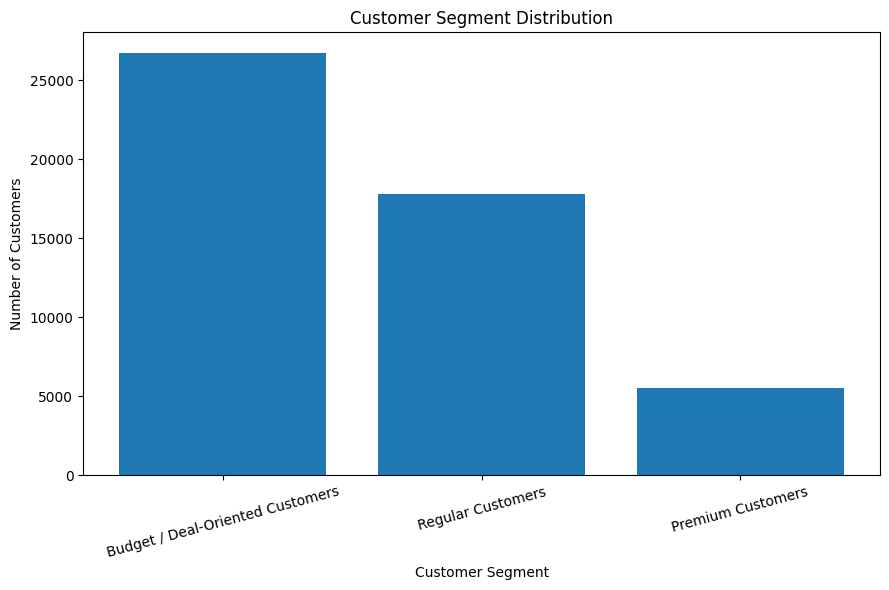

In [81]:
segment_counts = (
    segmented_df["Cluster_Name"]
    .value_counts()
)

plt.figure(figsize=(9, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values,
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

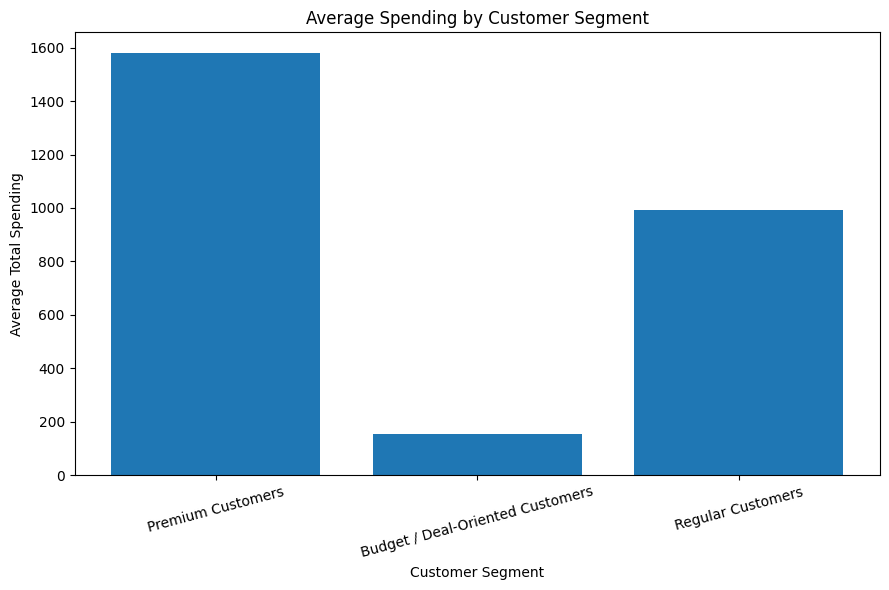

In [82]:
spending_plot = final_profile.reset_index()

plt.figure(figsize=(9, 6))

plt.bar(
    spending_plot["Cluster_Name"],
    spending_plot["TotalSpending"],
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending")
plt.title("Average Spending by Customer Segment")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

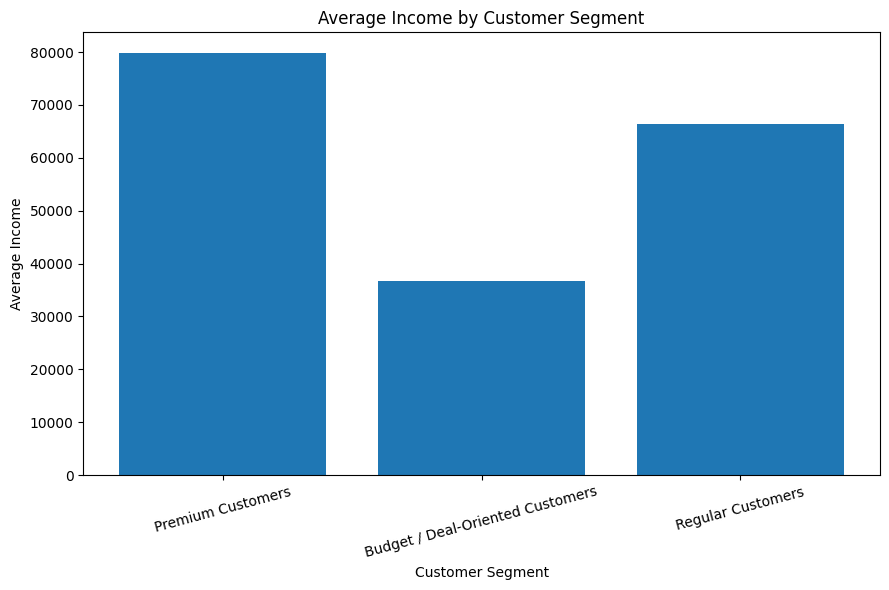

In [83]:
plt.figure(figsize=(9, 6))

plt.bar(
    spending_plot["Cluster_Name"],
    spending_plot["Income"],
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Income")
plt.title("Average Income by Customer Segment")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

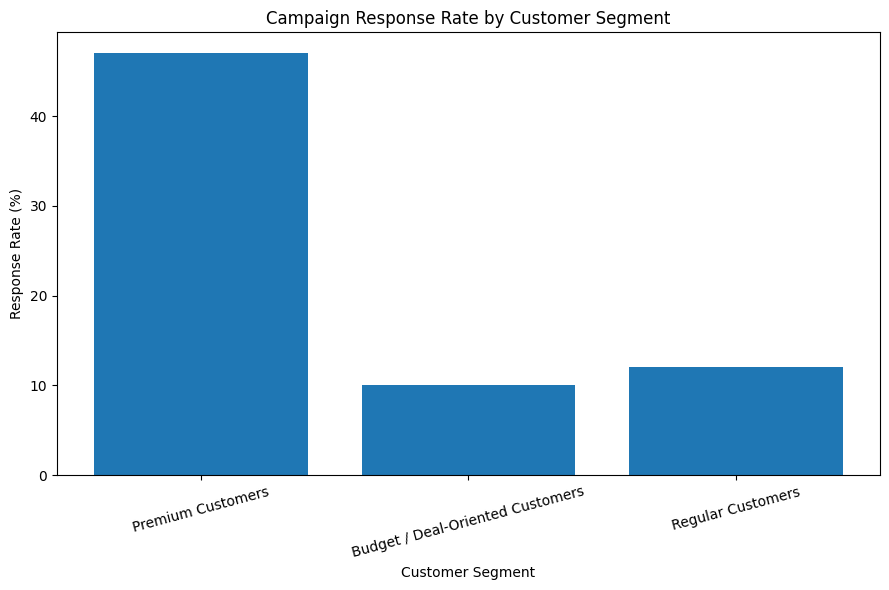

In [84]:
plt.figure(figsize=(9, 6))

plt.bar(
    spending_plot["Cluster_Name"],
    spending_plot["Response"] * 100,
)

plt.xlabel("Customer Segment")
plt.ylabel("Response Rate (%)")
plt.title("Campaign Response Rate by Customer Segment")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [86]:
recommendation_map = {
    "Premium Customers": (
        "Loyalty and premium-value strategy: "
        "offer premium products, loyalty rewards, and early access."
    ),
    "Budget / Deal-Oriented Customers": (
        "Value and discount strategy: "
        "use targeted discounts, bundles, and price-sensitive offers."
    ),
    "Regular Customers": (
        "Growth and cross-selling strategy: "
        "use personalized bundles, cross-sell offers, and loyalty incentives."
    ),
}

In [87]:
final_profile["Recommendation"] = (
    final_profile["Cluster_Name"]
    .map(recommendation_map)
)

final_profile

,Cluster_Name,CustomerCount,Age,Income,TotalChildren,CustomerTenureDays,Recency,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,NumWebVisitsMonth,CampaignAcceptedCount,Response,Complain,Recommendation
Cluster,,,,,,,,,,,,,,,,,,
0,Premium Customers,5537,44.21,79735.28,0.20,343.28,50.40,1578.39,19.95,0.07,0.27,0.31,0.42,3.08,1.79,0.47,0.00,Loyalty and premium-value strategy: offer prem...
1,Budget / Deal-Oriented Customers,26683,43.23,36627.73,1.28,339.48,48.68,152.61,6.95,0.43,0.36,0.09,0.54,6.67,0.10,0.10,0.01,Value and discount strategy: use targeted disc...
2,Regular Customers,17777,48.35,66399.59,0.67,378.06,49.70,993.70,18.78,0.13,0.30,0.25,0.45,3.92,0.13,0.12,0.01,Growth and cross-selling strategy: use persona...


In [88]:
print("recommendation_map" in globals())

True


In [89]:
from pathlib import Path

models_path = Path("../models")

print("Preprocessor exists:",
      (models_path / "preprocessor.pkl").exists())

print("Clustering model exists:",
      (models_path / "clustering_model.pkl").exists())

Preprocessor exists: True
Clustering model exists: True


In [91]:
import json

metadata = {
    "reference_year": int(reference_year),
    "reference_date": str(reference_date.date()),
    "final_k": int(FINAL_K),
    "cluster_names": cluster_name_map,
}

In [92]:
metadata_path = Path("../models/model_metadata.json")

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4)

print(f"Saved metadata to: {metadata_path}")

Saved metadata to: ..\models\model_metadata.json


In [94]:
test_customer = df.iloc[[0]].copy()

test_customer

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalChildren,CustomerTenureDays,TotalSpending,TotalPurchases,DealPurchaseShare,WebPurchaseShare,CatalogPurchaseShare,StorePurchaseShare,CampaignAcceptedCount
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,0,663,1617,22,0.136364,0.363636,0.454545,0.181818,0


In [98]:
test_customer.to_csv(
    "../data/processed/test_customer_input.csv",
    index=False,
)

print("Test customer saved.")

Test customer saved.


In [96]:
import json
from pathlib import Path

metadata = {
    "reference_year": int(reference_year),
    "reference_date": str(reference_date.date()),
    "final_k": int(FINAL_K),

    "cluster_names": {
        0: "Premium Customers",
        1: "Budget / Deal-Oriented Customers",
        2: "Regular Customers",
    },

    "recommendations": {
        "Premium Customers": (
            "Loyalty and premium-value strategy: "
            "offer premium products, loyalty rewards, and early access."
        ),

        "Budget / Deal-Oriented Customers": (
            "Value and discount strategy: "
            "use targeted discounts, bundles, and price-sensitive offers."
        ),

        "Regular Customers": (
            "Growth and cross-selling strategy: "
            "use personalized bundles, cross-sell offers, and loyalty incentives."
        ),
    },
}

metadata_path = Path("../models/model_metadata.json")

metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
    )

print("Model metadata saved successfully.")
print(f"Location: {metadata_path}")

Model metadata saved successfully.
Location: ..\models\model_metadata.json


In [100]:
test_customer = df.iloc[[0]].copy()

test_customer.to_csv(
    "../data/processed/test_customer_input.csv",
    index=False
)

print("Test customer file created.")
print(test_customer)

Test customer file created.
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  2012-09-04       58       635         88              546              172   

   MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  \
0                88            88                  3                8   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  \
0                   10                  4                  7             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  Response  \
0             0             0             0             0         0         1   

   Age  TotalChildren  CustomerTenureDays  TotalSpending  TotalPurchases  \
0   57              0                 663           1617              22   

   DealPurchaseShare  WebPurchas

In [101]:
test_customer = df.iloc[[0]].copy()

test_customer.to_csv(
    "../data/processed/test_customer_input.csv",
    index=False
)

print("Test customer created.")

Test customer created.
